# bar and area plot

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

HI_DIR = "HI_figs"
ONE_SR_DIR = "One_s_r_figs"


# ============================================================
# SWITCHING-RULE LABELS
# ============================================================

RULE_LABELS = {
    "noswitch": "No switching",
    "S_to_R": r"$S \rightarrow R$",
    "R_to_S": r"$R \rightarrow S$",
    "S_R": r"$S \leftrightarrow R$",
    "threshold": "Drug-threshold",
    "uptake": "Drug-threshold + drug uptake",
    "independent": "Independent switching",
}


# ============================================================
# IDENTIFY SWITCHING RULE
# ============================================================

def identify_rule(dirname):

    name = dirname.lower()

    # Order matters — check more specific names first

    if "independent_switch" in name:
        return "independent"

    if "doubleswitch" in name or "double_switch" in name:
        return "S_R"

    if "drug_threshold" in name:
        return "threshold"

    if "uptake" in name:
        return "uptake"

    if "noswitch" in name:
        return "noswitch"

    if "rs_switch" in name or name.endswith("_rs"):
        return "R_to_S"

    if "sr_switch" in name or name.endswith("_sr"):
        return "S_to_R"

    # HI folder naming
    if "allbd_rs" in name:
        return "R_to_S"

    if "allbd_sr" in name:
        return "S_to_R"

    if "doubleswitch" in name:
        return "S_R"

    if "drug_threshold" in name:
        return "threshold"

    return None


# ============================================================
# READ tot_area.csv
# ============================================================

def read_tot_area(filepath):

    df = pd.read_csv(filepath)

    # First column = MCS
    # Second column = total cell area

    mcs = df.iloc[:, 0].values
    area = df.iloc[:, 1].values

    return mcs, area


# ============================================================
# COLLECT DATA
# ============================================================

def collect_data(base_dir):

    results = []

    for dirname in sorted(os.listdir(base_dir)):

        full_dir = os.path.join(base_dir, dirname)

        if not os.path.isdir(full_dir):
            continue

        rule = identify_rule(dirname)

        if rule is None:
            print(f"WARNING: Could not identify rule: {dirname}")
            continue

        filepath = os.path.join(full_dir, "tot_area.csv")

        if not os.path.isfile(filepath):
            print(f"WARNING: No tot_area.csv in {full_dir}")
            continue

        mcs, area = read_tot_area(filepath)

        results.append({
            "directory": dirname,
            "rule": rule,
            "rule_label": RULE_LABELS[rule],
            "mcs": mcs,
            "area": area
        })

    return results


HI_data = collect_data(HI_DIR)
ONE_data = collect_data(ONE_SR_DIR)


print(f"\nFound {len(HI_data)} HI simulations")
print(f"Found {len(ONE_data)} 1:15 simulations")

print("\nHI:")
for x in HI_data:
    print(" ", x["directory"], "→", x["rule_label"])

print("\n1:15:")
for x in ONE_data:
    print(" ", x["directory"], "→", x["rule_label"])


Found 14 HI simulations
Found 14 1:15 simulations

HI:
  High_HI_all_bd_drug_threshold → Drug-threshold
  High_HI_allbd_RS → $R \rightarrow S$
  High_HI_allbd_SR → $S \rightarrow R$
  High_HI_allbd_doubleswitch → $S \leftrightarrow R$
  High_HI_allbd_noswitch → No switching
  High_HI_topbd_uptake → Drug-threshold + drug uptake
  Low_HI_all_bd_drug_threshold → Drug-threshold
  Low_HI_allbd_RS → $R \rightarrow S$
  Low_HI_allbd_SR → $S \rightarrow R$
  Low_HI_allbd_noswitch → No switching
  Low_HI_allbd_uptake → Drug-threshold + drug uptake
  independent_switch_highHI → Independent switching
  independent_switch_lowHI → Independent switching
  low_HI_allbd_doubleswitch → $S \leftrightarrow R$

1:15:
  drug_c1c2_RS_switch_oner → $R \rightarrow S$
  drug_c1c2_RS_switch_ones → $R \rightarrow S$
  drug_c1c2_SR_switch_oner → $S \rightarrow R$
  drug_c1c2_SR_switch_ones → $S \rightarrow R$
  drug_c1c2_noswitch_oner → No switching
  drug_c1c2_noswitch_ones → No switching
  drug_double_switch_o


DATA USED FOR BAR PLOT

Low HI
No switching                        | 2100 = 7180 | 4440 = 9560 | Low_HI_allbd_noswitch
$S \rightarrow R$                   | 2100 = 6795 | 4440 = 9326 | Low_HI_allbd_SR
$R \rightarrow S$                   | 2100 = 6656 | 4440 = 7696 | Low_HI_allbd_RS
$S \leftrightarrow R$               | 2100 = 6750 | 4440 = 8683 | low_HI_allbd_doubleswitch
Drug-threshold                      | 2100 = 6126 | 4440 = 6439 | Low_HI_all_bd_drug_threshold
Drug-threshold + drug uptake        | 2100 = 6427 | 4440 = 6792 | Low_HI_allbd_uptake
Independent switching               | 2100 = 6173 | 4440 = 6260 | independent_switch_lowHI

High HI
No switching                        | 2100 = 7587 | 4440 = 9752 | High_HI_allbd_noswitch
$S \rightarrow R$                   | 2100 = 7455 | 4440 = 9956 | High_HI_allbd_SR
$R \rightarrow S$                   | 2100 = 6882 | 4440 = 8766 | High_HI_allbd_RS
$S \leftrightarrow R$               | 2100 = 7197 | 4440 = 9397 | High_HI_allbd_doublesw

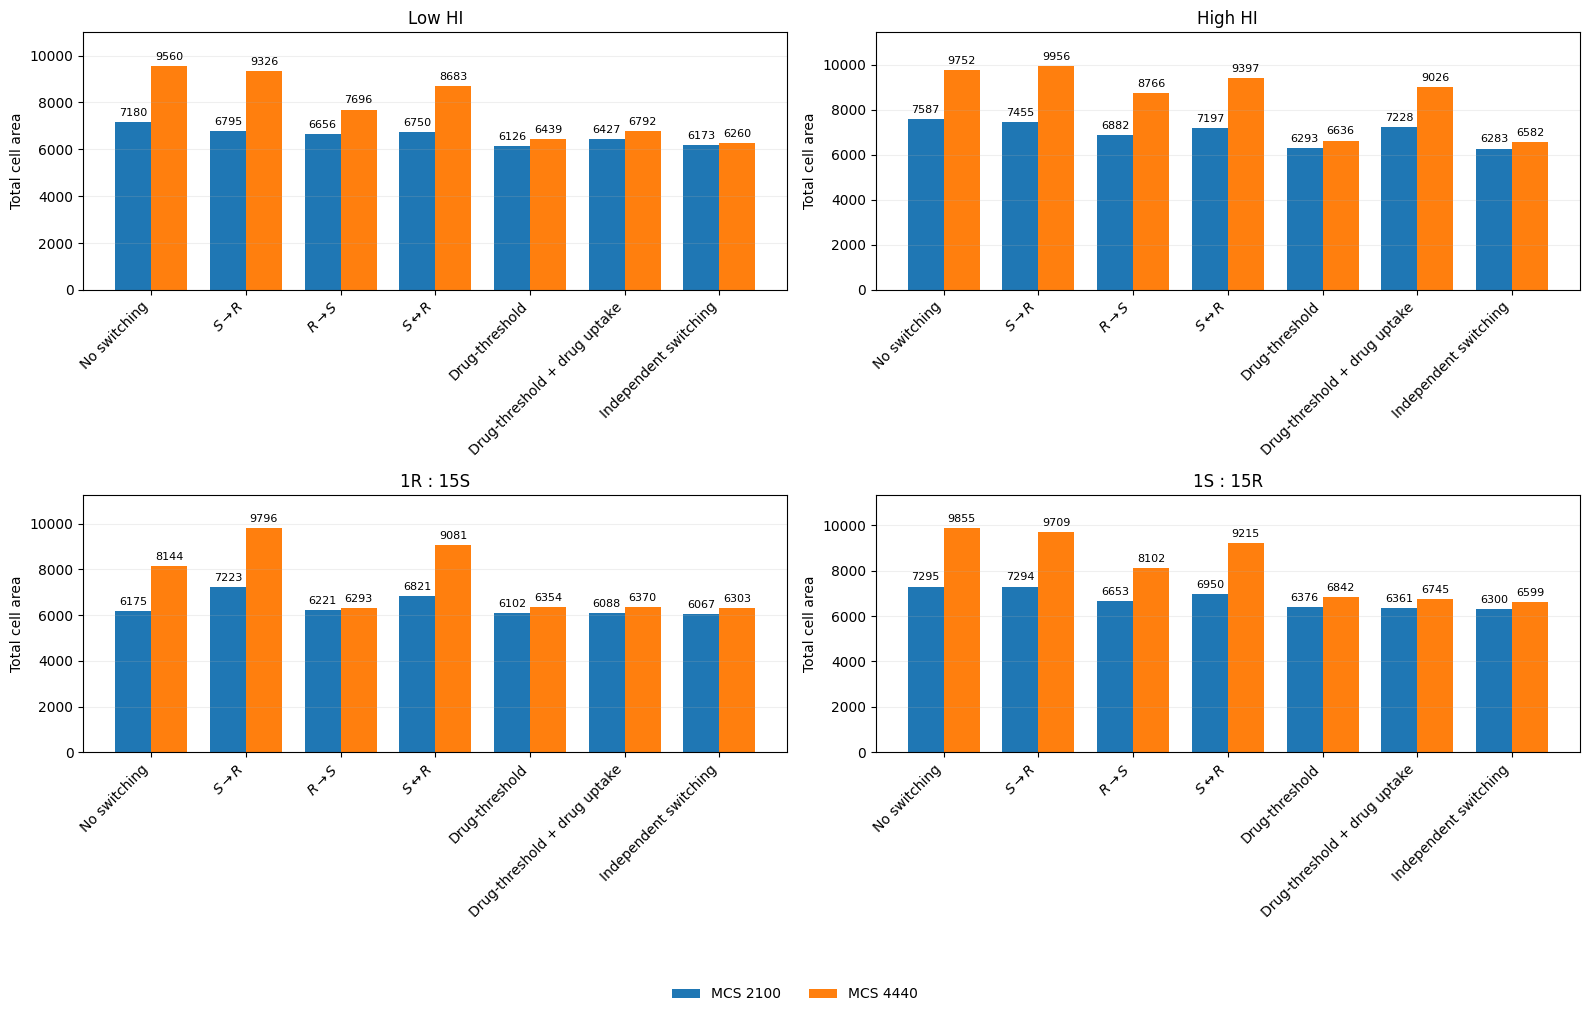

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FUNCTION: GET AREA AT SPECIFIC MCS
# ============================================================

def get_area_at_mcs(result, target_mcs):

    mcs = np.asarray(result["mcs"])
    area = np.asarray(result["area"])

    idx = np.argmin(np.abs(mcs - target_mcs))

    return area[idx], mcs[idx]


# ============================================================
# SWITCHING-RULE ORDER
# ============================================================

rule_order = [
    "noswitch",
    "S_to_R",
    "R_to_S",
    "S_R",
    "threshold",
    "uptake",
    "independent"
]


# ============================================================
# BUILD PANEL DATA — SAME LOGIC AS GROWTH CURVES
# ============================================================

panel_data = {
    "Low HI": [],
    "High HI": [],
    "1R : 15S": [],
    "1S : 15R": []
}


# ------------------------------------------------------------
# HI DATA
# ------------------------------------------------------------

for result in HI_data:

    name = result["directory"].lower()

    if "low_hi" in name or "lowhi" in name:
        panel_data["Low HI"].append(result)

    elif "high_hi" in name or "highhi" in name:
        panel_data["High HI"].append(result)


# ------------------------------------------------------------
# 1:15 DATA
# ------------------------------------------------------------

for result in ONE_data:

    name = result["directory"].lower()

    if name.endswith("_oner"):
        panel_data["1R : 15S"].append(result)

    elif name.endswith("_ones"):
        panel_data["1S : 15R"].append(result)


# ============================================================
# PRINT DATA USED IN BAR PLOT
# ============================================================

print("\n" + "=" * 80)
print("DATA USED FOR BAR PLOT")
print("=" * 80)

for panel, data in panel_data.items():

    print(f"\n{panel}")

    data = sorted(
        data,
        key=lambda r: rule_order.index(r["rule"])
    )

    for result in data:

        area_2100, actual_2100 = get_area_at_mcs(
            result, 2100
        )

        area_4440, actual_4440 = get_area_at_mcs(
            result, 4440
        )

        print(
            f"{result['rule_label']:35s} | "
            f"2100 = {area_2100:.0f} | "
            f"4440 = {area_4440:.0f} | "
            f"{result['directory']}"
        )

print("=" * 80)


# ============================================================
# FOUR-PANEL BAR FIGURE
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharey=False
)


conditions = [
    ("Low HI", axes[0, 0]),
    ("High HI", axes[0, 1]),
    ("1R : 15S", axes[1, 0]),
    ("1S : 15R", axes[1, 1])
]


for title, ax in conditions:

    data = sorted(
        panel_data[title],
        key=lambda r: rule_order.index(r["rule"])
    )

    labels = []
    area_2100 = []
    area_4440 = []

    for result in data:

        value_2100, _ = get_area_at_mcs(
            result, 2100
        )

        value_4440, _ = get_area_at_mcs(
            result, 4440
        )

        labels.append(result["rule_label"])
        area_2100.append(value_2100)
        area_4440.append(value_4440)


    # --------------------------------------------------------
    # BAR POSITIONS
    # --------------------------------------------------------

    x = np.arange(len(labels))
    width = 0.38

    bars_2100 = ax.bar(
        x - width / 2,
        area_2100,
        width,
        label="MCS 2100"
    )

    bars_4440 = ax.bar(
        x + width / 2,
        area_4440,
        width,
        label="MCS 4440"
    )


    # --------------------------------------------------------
    # VALUE LABELS
    # --------------------------------------------------------

    ax.bar_label(
        bars_2100,
        labels=[f"{v:.0f}" for v in area_2100],
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        bars_4440,
        labels=[f"{v:.0f}" for v in area_4440],
        padding=3,
        fontsize=8
    )


    # --------------------------------------------------------
    # FORMAT
    # --------------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_title(title)

    ax.set_ylabel("Total cell area")

    ax.grid(
        axis="y",
        alpha=0.2
    )

    ax.margins(y=0.15)


# ============================================================
# LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=False
)


plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()

Saved: growth_curves.png


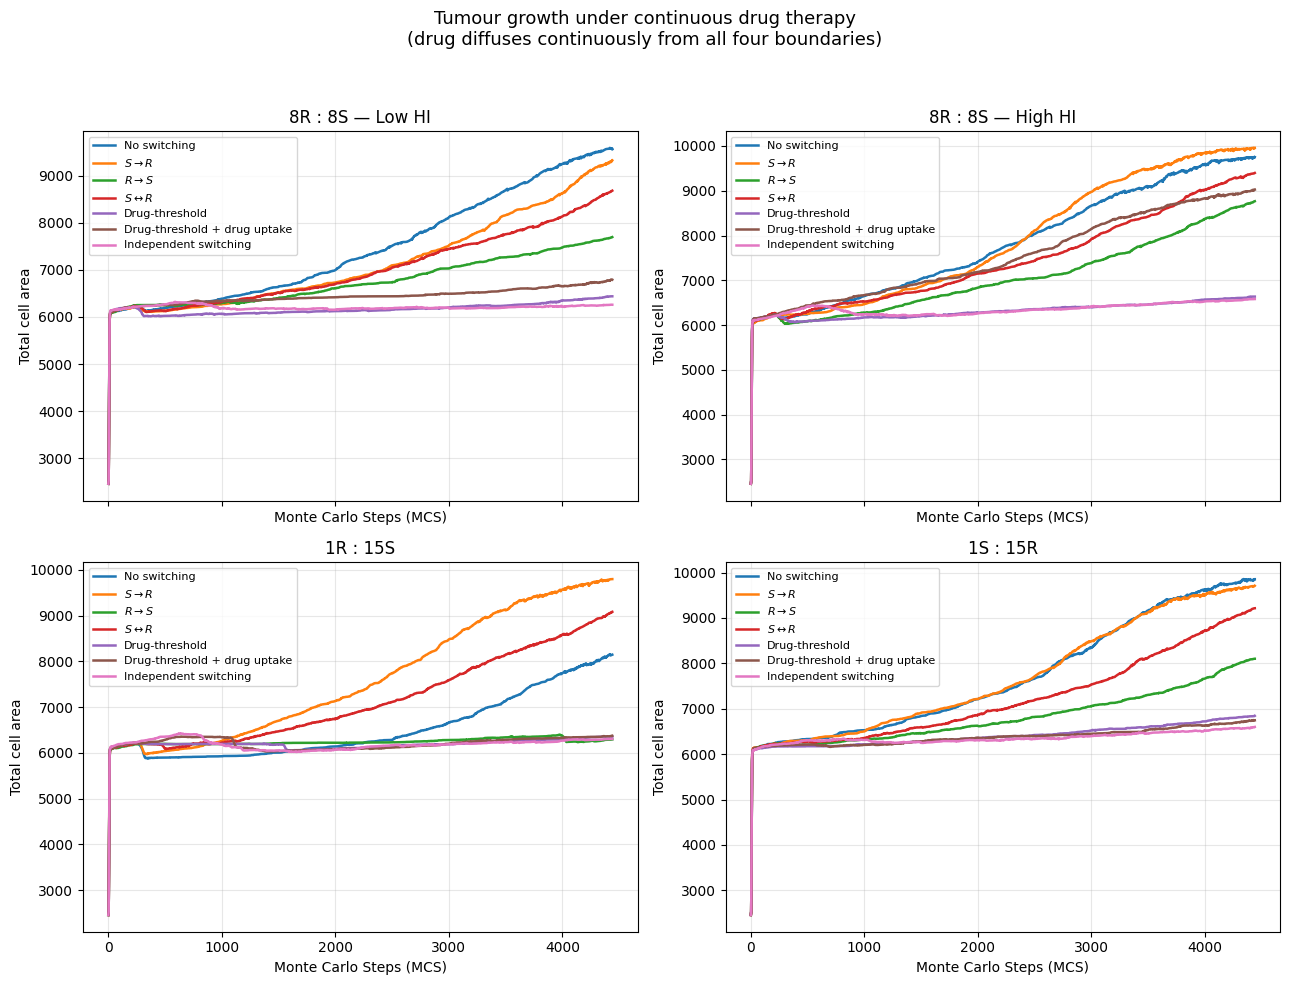

In [11]:
"""
CC3D tumour growth analysis: growth curves
=================================================================

Fixes the mis-colouring bug from the previous version, which relied on
fuzzy substring matching (e.g. `"SR" in dirname`, `"switch" in dirname`)
to infer the switching rule. That approach is inherently ambiguous here
because "noswitch" also contains "switch", and several directory names
differ only in RS vs SR ordering. If a broad check (like `"switch" in
name`) was evaluated after a more specific one, it could silently
overwrite an already-correct rule assignment -- which is exactly the
symptom described (a "no switching" curve appearing as "S -> R").

The fix: every directory name is mapped to exactly one canonical rule
key via an explicit, exhaustive lookup table built directly from the
directory listing. No substring inference is used anywhere.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------
HI_DIR = "HI_figs"
ONE_SR_DIR = "One_s_r_figs"

# --------------------------------------------------------------------
# Canonical rule keys, labels, plotting order, and colours
# --------------------------------------------------------------------
RULE_LABELS = {
    "noswitch":    "No switching",
    "S_to_R":      r"$S \rightarrow R$",
    "R_to_S":      r"$R \rightarrow S$",
    "S_R":         r"$S \leftrightarrow R$",
    "threshold":   "Drug-threshold",
    "uptake":      "Drug-threshold + drug uptake",
    "independent": "Independent switching",
}

rule_order = [
    "noswitch",
    "S_to_R",
    "R_to_S",
    "S_R",
    "threshold",
    "uptake",
    "independent",
]

# Fixed colour per rule, shared across every panel and every figure.
_palette = plt.get_cmap("tab10").colors
RULE_COLORS = {rule: _palette[i] for i, rule in enumerate(rule_order)}

# --------------------------------------------------------------------
# EXPLICIT directory -> rule mapping (no substring inference)
# --------------------------------------------------------------------
# HI_figs (8R:8S), High HI
HIGH_HI_DIRS = {
    "High_HI_allbd_noswitch":         "noswitch",
    "High_HI_allbd_SR":               "S_to_R",
    "High_HI_allbd_RS":               "R_to_S",
    "High_HI_allbd_doubleswitch":     "S_R",
    "High_HI_all_bd_drug_threshold":  "threshold",
    "High_HI_topbd_uptake":           "uptake",
    "independent_switch_highHI":      "independent",
}

# HI_figs (8R:8S), Low HI
LOW_HI_DIRS = {
    "Low_HI_allbd_noswitch":          "noswitch",
    "Low_HI_allbd_SR":                "S_to_R",
    "Low_HI_allbd_RS":                "R_to_S",
    "low_HI_allbd_doubleswitch":      "S_R",
    "Low_HI_all_bd_drug_threshold":   "threshold",
    "Low_HI_allbd_uptake":            "uptake",
    "independent_switch_lowHI":       "independent",
}

# One_s_r_figs, 1R:15S ("_oner")
ONER_DIRS = {
    "drug_c1c2_noswitch_oner":        "noswitch",
    "drug_c1c2_SR_switch_oner":       "S_to_R",
    "drug_c1c2_RS_switch_oner":       "R_to_S",
    "drug_double_switch_oner":        "S_R",
    "drug_threshold_switch_oner":     "threshold",
    "drug_uptake_oner":               "uptake",
    "drug_independent_switch_oner":   "independent",
}

# One_s_r_figs, 1S:15R ("_ones")
ONES_DIRS = {
    "drug_c1c2_noswitch_ones":        "noswitch",
    "drug_c1c2_SR_switch_ones":       "S_to_R",
    "drug_c1c2_RS_switch_ones":       "R_to_S",
    "drug_double_switch_ones":        "S_R",
    "drug_threshold_switch_ones":     "threshold",
    "drug_uptake_ones":               "uptake",
    "drug_independent_switch_ones":   "independent",
}

# panel key -> (base directory, {dirname: rule})
PANEL_SPECS = {
    "low_hi":  (HI_DIR, LOW_HI_DIRS),
    "high_hi": (HI_DIR, HIGH_HI_DIRS),
    "oner":    (ONE_SR_DIR, ONER_DIRS),
    "ones":    (ONE_SR_DIR, ONES_DIRS),
}

PANEL_TITLES = {
    "low_hi":  "8R : 8S — Low HI",
    "high_hi": "8R : 8S — High HI",
    "oner":    "1R : 15S",
    "ones":    "1S : 15R",
}

# --------------------------------------------------------------------
# Optional sanity check against manually-verified endpoint values
# (from the endpoint diagnostic). Used only to flag data-reading
# problems early -- not used to plot anything.
# --------------------------------------------------------------------
VERIFIED_FINAL = {
    "High_HI_all_bd_drug_threshold": 6636,
    "High_HI_allbd_RS": 8766,
    "High_HI_allbd_SR": 9956,
    "High_HI_allbd_doubleswitch": 9397,
    "High_HI_allbd_noswitch": 9752,
    "High_HI_topbd_uptake": 9026,
    "independent_switch_highHI": 6582,
    "Low_HI_all_bd_drug_threshold": 6439,
    "Low_HI_allbd_RS": 7696,
    "Low_HI_allbd_SR": 9326,
    "Low_HI_allbd_noswitch": 9560,
    "Low_HI_allbd_uptake": 6792,
    "independent_switch_lowHI": 6260,
    "low_HI_allbd_doubleswitch": 8683,
    "drug_c1c2_RS_switch_oner": 6293,
    "drug_c1c2_SR_switch_oner": 9796,
    "drug_c1c2_noswitch_oner": 8144,
    "drug_double_switch_oner": 9081,
    "drug_independent_switch_oner": 6303,
    "drug_threshold_switch_oner": 6354,
    "drug_uptake_oner": 6370,
    "drug_c1c2_RS_switch_ones": 8102,
    "drug_c1c2_SR_switch_ones": 9709,
    "drug_c1c2_noswitch_ones": 9855,
    "drug_double_switch_ones": 9215,
    "drug_independent_switch_ones": 6599,
    "drug_threshold_switch_ones": 6842,
    "drug_uptake_ones": 6745,
}

# --------------------------------------------------------------------
# CSV reader -- reads first two columns BY POSITION (headers vary)
# --------------------------------------------------------------------
def read_tot_area(filepath):
    df = pd.read_csv(filepath)
    mcs = df.iloc[:, 0].values.astype(float)
    area = df.iloc[:, 1].values.astype(float)
    return mcs, area


# --------------------------------------------------------------------
# Load all data
# --------------------------------------------------------------------
def load_all_data():
    """
    Returns dict: panel_key -> list of result dicts, each:
        {
            "directory": dirname,
            "panel": panel_key,
            "rule": rule_key,
            "rule_label": RULE_LABELS[rule_key],
            "mcs": array,
            "area": array,
        }
    """
    all_data = {panel: [] for panel in PANEL_SPECS}
    missing = []

    for panel_key, (base_dir, dir_rule_map) in PANEL_SPECS.items():
        for dirname, rule in dir_rule_map.items():
            filepath = os.path.join(base_dir, dirname, "tot_area.csv")
            if not os.path.exists(filepath):
                missing.append(filepath)
                continue

            mcs, area = read_tot_area(filepath)

            # Sanity check against the verified endpoint diagnostic.
            if dirname in VERIFIED_FINAL:
                expected = VERIFIED_FINAL[dirname]
                actual = area[-1]
                if abs(actual - expected) > 1e-6:
                    print(
                        f"[WARNING] {dirname}: final area read = {actual}, "
                        f"expected (verified) = {expected}. "
                        f"Check that the CSV / directory matches the rule '{rule}'."
                    )

            all_data[panel_key].append({
                "directory": dirname,
                "panel": panel_key,
                "rule": rule,
                "rule_label": RULE_LABELS[rule],
                "mcs": mcs,
                "area": area,
            })

    if missing:
        print(f"[WARNING] {len(missing)} tot_area.csv file(s) not found:")
        for m in missing:
            print("   ", m)

    # Sort each panel's entries into the canonical rule_order for
    # consistent legend / bar ordering.
    for panel_key in all_data:
        all_data[panel_key].sort(
            key=lambda r: rule_order.index(r["rule"])
            if r["rule"] in rule_order else len(rule_order)
        )

    return all_data


# --------------------------------------------------------------------
# Figure 1: four-panel growth curves
# --------------------------------------------------------------------
def plot_growth_curves(all_data, savepath="growth_curves.png"):
    panel_order = ["low_hi", "high_hi", "oner", "ones"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True)
    axes = axes.ravel()

    for ax, panel_key in zip(axes, panel_order):
        results = all_data[panel_key]
        for res in results:
            rule = res["rule"]
            ax.plot(
                res["mcs"], res["area"],
                color=RULE_COLORS[rule],
                label=res["rule_label"],
                linewidth=1.8,
            )
        ax.set_title(PANEL_TITLES[panel_key], fontsize=12)
        ax.set_xlabel("Monte Carlo Steps (MCS)")
        ax.set_ylabel("Total cell area")
        ax.grid(alpha=0.3)

        # Legend ordered per rule_order, deduplicated, only rules present.
        handles, labels = ax.get_legend_handles_labels()
        present_rules = [r["rule"] for r in results]
        order_idx = sorted(
            range(len(labels)),
            key=lambda i: rule_order.index(present_rules[i])
        )
        ax.legend(
            [handles[i] for i in order_idx],
            [labels[i] for i in order_idx],
            fontsize=8, loc="upper left"
        )

    fig.suptitle(
        "Tumour growth under continuous drug therapy\n"
        "(drug diffuses continuously from all four boundaries)",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(savepath, dpi=200)
    print(f"Saved: {savepath}")
    return fig


# --------------------------------------------------------------------
# Main
# --------------------------------------------------------------------
if __name__ == "__main__":
    all_data = load_all_data()
    plot_growth_curves(all_data, savepath="growth_curves.png")
    plt.show()